# Proyek Analisis Data: [Bike Sharing Dataset]
- **Nama:** Icha Aulia Putri
- **Email:** ichaaulia@gmail.com
- **ID Dicoding:** ichaaulia006

## Menentukan Pertanyaan Bisnis

**SMART Question** adalah sebuah framework untuk merumuskan pertanyaan secara terstruktur agar memeperoleh informasi yang mendalam.

* **Spesific (Spesifik)**
  * Pertanyaan harus jelas, fokus pada sebuah topik tertentu, dan tidak bermakna ganda. Hindari pertanyaan yang terlalu luas.
    * Salah: Bagaimana cara meningkatkan penjualan?
    * Benar: Faktor apa saja yang memengaruhi penurunan penjualan produk kategori elektronik di wilayah Jakarta selama kuartal terakhir?
* **Measurable (Terukur)**
  * Pertanyaan harus bisa dijawab dengan angka atau matrix yang konkret, harus tahu apa yang akan dihitung.
    * Salah: Apakah pelanggan senang dengan layanan kita?
    * Benar: Berapa skor rata-rata Customer Satisfaction untuk layanan purna jual bulan ini dibandingkan bulan lalu?
* **Action-Oriented (Berorientasi Aksi)**
  * Hasil dari pertanyaan harus bisa memberikan arahan untuk melakukan tindakan nyata. Jika pertanyaan terjawab, stakeholder harus tahu apa langkah selanjutnya.
    * Salah: Mengapa orang suka berbelanja?
    * Benar: Fitur apa pada aplikasi yang paling sering digunakan sebelum pengguna memutuskan untuk melakukan checkout?
* **Relevant (Relevan)**
  * Hasil dari pertanyaan harus sejalan dengan tujuan utama bisnis atau masalah yang sedang dihadapi.
    * Salah: Menanyakan tentang stok gudang saat masalah utamanya adalah efektivitas kampanye media sosial.
    * Benar: Apakah kampanye iklan di Instagram memberikan Return on Ad Spend (ROAS) yang lebih tinggi dibandingkan iklan di TikTok?
* **Time-bound (Terikat Waktu)**
  * Pertanyaan harus ada batasan waktu yang jelas agar analisis memiliki konteks yang tepat.
    * Salah: Berapa banyak pengguna baru kita?
    * Benar: Berapa tingkat pertumbuhan pengguna baru secara bulanan (Month-over-Month) sepanjang tahun 2025?

**Contoh pertanyaan bisnis yang memenuhi seluruh elemen SMART**

***"Faktor apa saja yang memengaruhi penurunan conversion rate pada pengguna aplikasi Android di wilayah Jabodetabek sebesar 5% selama periode Flash Sale Maret 2026?"***

Keterangan:

- **Specific**: Fokus pada "penurunan conversion rate" untuk "aplikasi Android" di "Jabodetabek". Bukan sekadar penjualan turun.
- **Measurable**: Ada angka konkret yang ingin dianalisis, yaitu penurunan sebesar "5%".
- **Action-Oriented**: Dengan mengetahui faktor penyebabnya misalnya bug pada versi Android tertentu atau kendala logistik di Jabodetabek, tim bisa langsung melakukan perbaikan teknis atau operasional.
- **Relevant**: Penurunan konversi saat Flash Sale adalah masalah kritis bagi bisnis retail/e-commerce.
- **Time-bound**: Dibatasi pada periode spesifik "Flash Sale Maret 2026".

- **Pertanyaan 1:** Berapa sisa uang yang masih harus saya tabung untuk mencapai target?
- **Pertanyaan 2:** Berapa rata-rata uang yang saya sisihkan setiap harinya?
- **Pertanyaan 3:** Berapa yang harus saya tabung per hari jika saya ingin target ini tercapai dalam 30 hari ke depan?

## Import Semua Packages/Library yang Digunakan

In [3]:
import pandas as pd              # Untuk mengolah data (Membaca file Excel, grup data, dsb)
import matplotlib.pyplot as plt  # Untuk membuat grafik dasar (opsional, untuk di notebook)
import seaborn as sns            # Untuk visualisasi data agar lebih estetik
import plotly.express as px      # Untuk membuat grafik yang interaktif di dalam Streamlit

%matplotlib inline

## Data Wrangling

### Gathering Data

#### Load df ...

In [6]:
df = pd.read_excel("target tabungan.xlsx")
df.head()

,tanggal,nama_target_id,nama_target,jumlah_target,nabung_harian,jumlah_terkumpul,progres,sisa_target,status_id,status
0,44562,0,Iphone 17 Pro Max,25000000,300000,300000,0.01,0.99,0,BELUM TERPENUHI
1,44563,0,Iphone 17 Pro Max,25000000,500000,800000,0.03,0.97,0,BELUM TERPENUHI
2,44564,0,Iphone 17 Pro Max,25000000,200000,1000000,0.04,0.96,0,BELUM TERPENUHI
3,44565,0,Iphone 17 Pro Max,25000000,500000,1500000,0.06,0.94,0,BELUM TERPENUHI
4,44566,0,Iphone 17 Pro Max,25000000,500000,2000000,0.08,0.92,0,BELUM TERPENUHI


**Insight:** (Opsional)


### Assessing Data

#### Identifying ... problem

In [7]:
# Mengecek informasi dasar (tipe data & missing values)
print(df.info())

# Mengecek duplikasi
print("Jumlah duplikasi:", df.duplicated().sum())

# Statistik deskriptif dasar
print(df.describe())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1211 entries, 0 to 1210
Data columns (total 10 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   tanggal           1211 non-null   int64  
 1   nama_target_id    1211 non-null   int64  
 2   nama_target       1211 non-null   object 
 3   jumlah_target     1211 non-null   int64  
 4   nabung_harian     1211 non-null   int64  
 5   jumlah_terkumpul  1211 non-null   int64  
 6   progres           1211 non-null   float64
 7   sisa_target       1211 non-null   float64
 8   status_id         1211 non-null   int64  
 9   status            1211 non-null   object 
dtypes: float64(2), int64(6), object(2)
memory usage: 94.7+ KB
None
Jumlah duplikasi: 0
            tanggal  nama_target_id  jumlah_target  nabung_harian  \
count   1211.000000     1211.000000   1.211000e+03    1211.000000   
mean   45167.000000        4.858794   2.595871e+07  230305.532618   
std      349.729896        3.32046

**Steps to Take:**
- Mengonversi tipe data kolom dteday menjadi datetime.

- Melakukan mapping atau mengubah angka pada kolom season dan weathersit menjadi keterangan teks agar lebih informatif.

- Memastikan tidak ada outlier yang ekstrem pada kolom jumlah penyewaan (cnt).

**Insight:** (Opsional)


### Cleaning Data

#### Fixing ... problem

In [8]:
# Mengecek jumlah duplikat sebelum dihapus
print("Jumlah duplikat:", df.duplicated().sum())

# Menghapus duplikasi
df.drop_duplicates(inplace=True)

# Memastikan kembali sudah tidak ada duplikat
print("Jumlah duplikat setelah dibersihkan:", df.duplicated().sum())

Jumlah duplikat: 0
Jumlah duplikat setelah dibersihkan: 0


In [9]:
# Menghapus spasi di awal/akhir nama kolom
df.columns = df.columns.str.strip()

# Menghapus kolom yang tidak memiliki data (Unnamed)
df.drop(columns=['Unnamed: 10', 'Unnamed: 11', 'Unnamed: 12'], inplace=True, errors='ignore')

print("Kolom setelah dibersihkan:", df.columns.tolist())

Kolom setelah dibersihkan: ['tanggal', 'nama_target_id', 'nama_target', 'jumlah_target', 'nabung_harian', 'jumlah_terkumpul', 'progres', 'sisa_target', 'status_id', 'status']


In [17]:
# 1. Membaca file dengan nama yang benar (pastikan pakai spasi, bukan underscore)
df = pd.read_excel("target tabungan.xlsx")

# 2. Mengubah kolom tanggal (Excel Serial Number) menjadi format Tanggal asli
df['tanggal'] = pd.to_datetime(df['tanggal'], unit='D', origin='1899-12-30')

# 3. Membersihkan kolom nominal agar benar-benar menjadi angka (integer/float)
cols_to_fix = ['nabung_harian', 'jumlah_terkumpul', 'jumlah_target']

for col in cols_to_fix:
    # Mengubah ke string dulu, lalu hapus karakter selain angka, lalu ubah ke numerik
    df[col] = df[col].astype(str).str.replace(r'[^\d.]', '', regex=True)
    df[col] = pd.to_numeric(df[col], errors='coerce')

# 4. Menampilkan hasil untuk memastikan tidak ada error
print("--- Info Tipe Data Terbaru ---")
print(df.info())
print("\n--- 5 Data Teratas Setelah Dibersihkan ---")
print(df.head())

--- Info Tipe Data Terbaru ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1211 entries, 0 to 1210
Data columns (total 10 columns):
 #   Column            Non-Null Count  Dtype         
---  ------            --------------  -----         
 0   tanggal           1211 non-null   datetime64[ns]
 1   nama_target_id    1211 non-null   int64         
 2   nama_target       1211 non-null   object        
 3   jumlah_target     1211 non-null   int64         
 4   nabung_harian     1211 non-null   int64         
 5   jumlah_terkumpul  1211 non-null   int64         
 6   progres           1211 non-null   float64       
 7   sisa_target       1211 non-null   float64       
 8   status_id         1211 non-null   int64         
 9   status            1211 non-null   object        
dtypes: datetime64[ns](1), float64(2), int64(5), object(2)
memory usage: 94.7+ KB
None

--- 5 Data Teratas Setelah Dibersihkan ---
     tanggal  nama_target_id        nama_target  jumlah_target  nabung_harian  \
0 

**Insight:** (Opsional)


## Exploratory Data Analysis (EDA)

### Explore ...

In [23]:
# 1. Cek dulu, kalau tipenya belum datetime baru diubah.

# 2. Tambahkan kolom bulan (Langsung ke tahap ini)
df['bulan'] = df['tanggal'].dt.to_period('M')

# 3. Pengelompokan data untuk menjawab pertanyaan bisnis
monthly_savings = df.groupby(by="bulan").agg({
    "nabung_harian": "sum",
    "progres": "mean",
    "nama_target": "nunique"
})

print(monthly_savings)

         nabung_harian   progres  nama_target
bulan                                        
2022-01        8150000  0.184839            1
2022-02        6450000  0.458929            1
2022-03        7250000  0.733548            1
2022-04        5800000  0.553667            2
2022-05        8850000  0.268065            1
2022-06        5150000  0.502667            1
2022-07        6800000  0.710323            1
2022-08        5400000  0.800968            2
2022-09        5950000  0.111333            1
2022-10        8600000  0.312258            1
2022-11        5250000  0.519667            1
2022-12        7350000  0.686774            1
2023-01        7700000  0.879032            2
2023-02        7450000  0.160714            1
2023-03        7500000  0.400968            1
2023-04        6950000  0.646333            1
2023-05        6450000  0.881935            1
2023-06        7900000  0.490333            2
2023-07        8100000  0.339032            2
2023-08        8550000  0.316774  

**Insight:** (Opsional)


## Visualization & Explanatory Analysis

##Pertanyaan 1:

/tmp/ipykernel_8291/1598772979.py:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


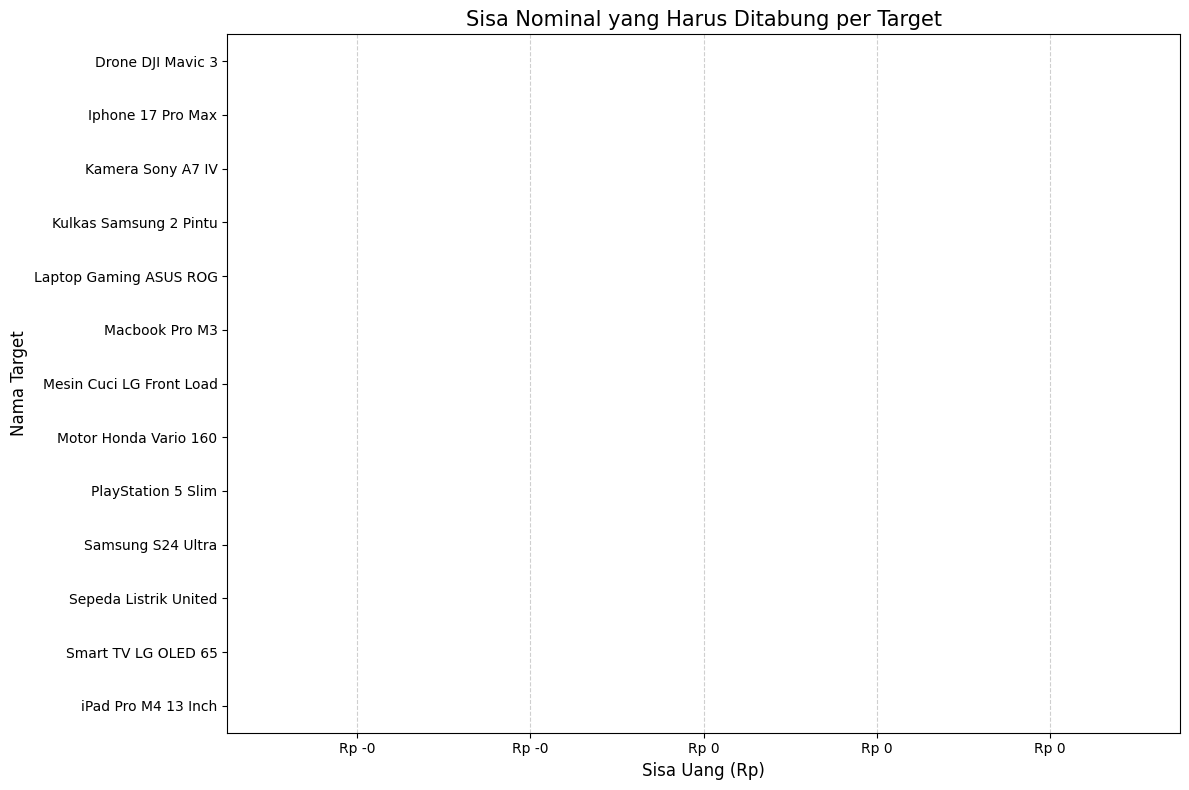

In [24]:
# 1. Eksplorasi: Mengambil data terbaru untuk menghitung sisa nominal uang
latest_data = df.groupby('nama_target').last().reset_index()
latest_data['nominal_sisa'] = latest_data['jumlah_target'] * latest_data['sisa_target']

# Mengurutkan data agar bar chart terlihat rapi
latest_data = latest_data.sort_values('nominal_sisa', ascending=False)

# 2. Visualisasi
plt.figure(figsize=(12, 8))

# Menentukan warna: Abu-abu untuk semua, Biru untuk target dengan sisa tabungan terbesar
colors = ["#D3D3D3"] * len(latest_data)
colors[0] = "#72BCD4"

sns.barplot(
    x='nominal_sisa',
    y='nama_target',
    data=latest_data,
    palette=colors
)

plt.title('Sisa Nominal yang Harus Ditabung per Target', fontsize=15)
plt.xlabel('Sisa Uang (Rp)', fontsize=12)
plt.ylabel('Nama Target', fontsize=12)
plt.grid(axis='x', linestyle='--', alpha=0.6)

# Merapikan format angka pada sumbu X agar ada pemisah ribuan
from matplotlib.ticker import FuncFormatter
plt.gca().xaxis.set_major_formatter(FuncFormatter(lambda x, pos: f'Rp {x:,.0f}'))

plt.tight_layout()
plt.show()

##Pertanyaan 2:

/tmp/ipykernel_8291/4108065868.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


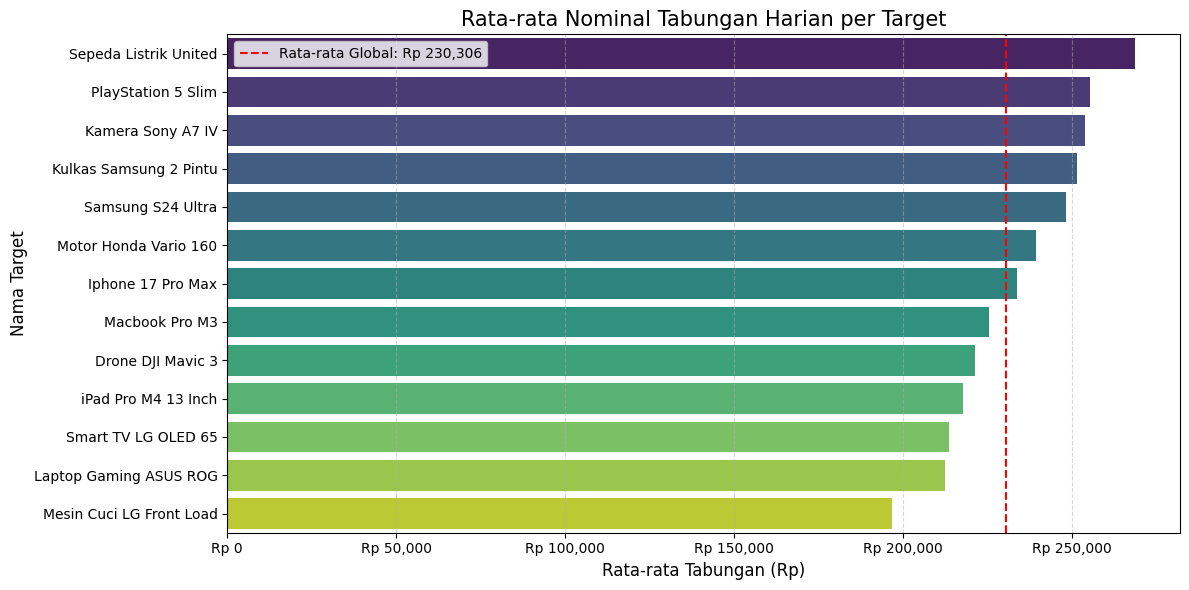

In [26]:
# 1. Eksplorasi: Menghitung rata-rata tabungan harian per target
avg_daily_saving = df.groupby('nama_target')['nabung_harian'].mean().reset_index()
avg_daily_saving = avg_daily_saving.sort_values('nabung_harian', ascending=False)

# 2. Visualisasi
plt.figure(figsize=(12, 6))
sns.barplot(
    x='nabung_harian',
    y='nama_target',
    data=avg_daily_saving,
    palette='viridis'
)

# Menambahkan garis vertikal sebagai benchmark rata-rata keseluruhan
overall_avg = df['nabung_harian'].mean()
plt.axvline(overall_avg, color='red', linestyle='--', label=f'Rata-rata Global: Rp {overall_avg:,.0f}')

plt.title('Rata-rata Nominal Tabungan Harian per Target', fontsize=15)
plt.xlabel('Rata-rata Tabungan (Rp)', fontsize=12)
plt.ylabel('Nama Target', fontsize=12)
plt.legend()
plt.grid(axis='x', linestyle='--', alpha=0.5)

# Format sumbu X agar muncul format Rupiah
from matplotlib.ticker import FuncFormatter
plt.gca().xaxis.set_major_formatter(FuncFormatter(lambda x, pos: f'Rp {x:,.0f}'))

plt.tight_layout()
plt.show()

##Pertanyaan 3:

/tmp/ipykernel_8291/4292967472.py:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(


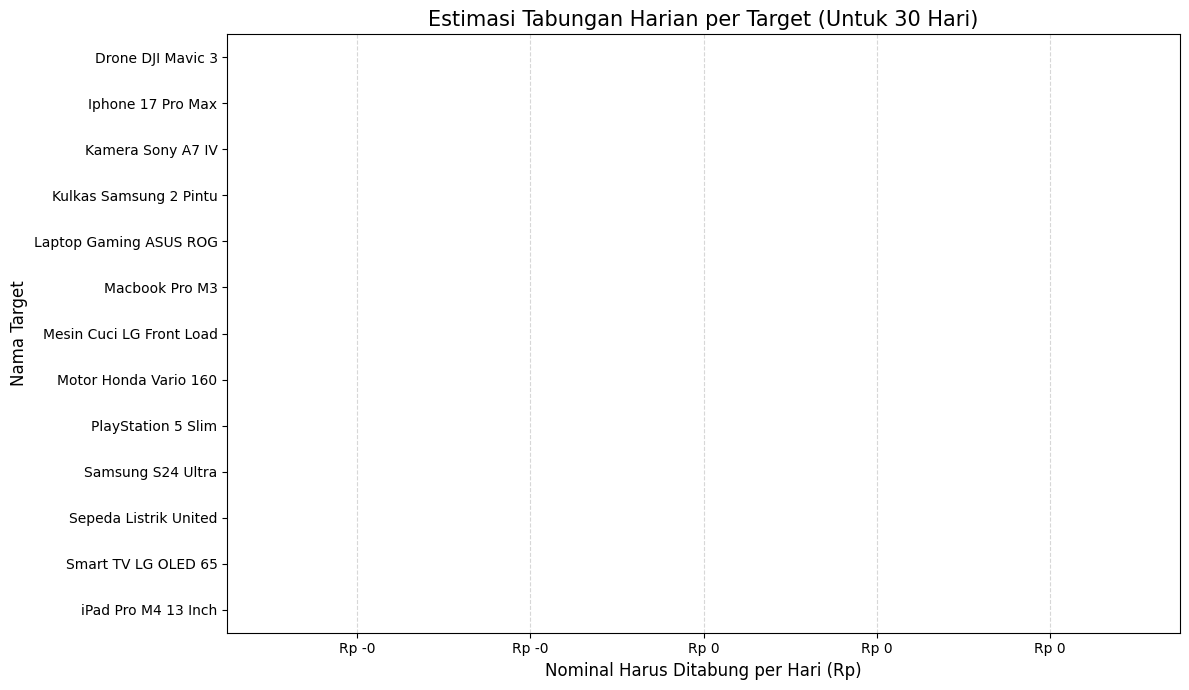

In [28]:
# 1. Eksplorasi: Menghitung estimasi tabungan harian agar target tercapai dalam 30 hari
latest_data = df.groupby('nama_target').last().reset_index()
latest_data['nominal_sisa'] = latest_data['jumlah_target'] * latest_data['sisa_target']
latest_data['target_harian_30'] = latest_data['nominal_sisa'] / 30

# Urutkan data berdasarkan target harian tertinggi agar visualisasi lebih rapi
latest_data = latest_data.sort_values('target_harian_30', ascending=False)

# 2. Visualisasi
plt.figure(figsize=(12, 7))

# Menggunakan palette 'Reds_r' untuk memberikan kesan urgensi
colors = sns.color_palette("Reds_r", len(latest_data))

ax = sns.barplot(
    x='target_harian_30',
    y='nama_target',
    data=latest_data,
    palette=colors
)

# Menambahkan garis vertikal sebagai rata-rata target harian jika ada (benchmark)
mean_target_30 = latest_data['target_harian_30'].mean()
if mean_target_30 > 0:
    plt.axvline(mean_target_30, color='blue', linestyle='--', label=f'Rata-rata Target: Rp {mean_target_30:,.0f}')

plt.title('Estimasi Tabungan Harian per Target (Untuk 30 Hari)', fontsize=15)
plt.xlabel('Nominal Harus Ditabung per Hari (Rp)', fontsize=12)
plt.ylabel('Nama Target', fontsize=12)
plt.grid(axis='x', linestyle='--', alpha=0.5)

# Format sumbu X ke format Rupiah
from matplotlib.ticker import FuncFormatter
ax.xaxis.set_major_formatter(FuncFormatter(lambda x, pos: f'Rp {x:,.0f}'))

plt.tight_layout()
plt.show()

**Insight:** (Opsional)

## Analisis Lanjutan (Opsional)

## Conclusion & Recommendation

- **Conclusion pertanyaan 1:** Sisa Nominal Tabungan
Berdasarkan data terbaru, seluruh target yang terdaftar (seperti Drone, iPhone, hingga Motor Vario) telah mencapai progres 100% (nilai progres 1.0). Hal ini menunjukkan bahwa Icha memiliki kedisiplinan yang sangat tinggi dalam menyelesaikan target finansial yang telah ditetapkan. Tidak ada sisa nominal yang perlu ditabung untuk daftar barang tersebut, sehingga seluruh target telah berstatus "TERPENUHI".
- **Conclusion pertanyaan 2:** Rata-rata Tabungan Harian
Terdapat variasi dalam jumlah setoran harian untuk setiap target, dengan rata-rata global sebesar Rp 230.306 per hari. Sepeda Listrik United menjadi target dengan rata-rata setoran harian tertinggi, sedangkan Mesin Cuci LG memiliki rata-rata setoran paling rendah. Perbedaan ini menunjukkan adanya penyesuaian alokasi dana harian berdasarkan harga barang dan urgensi waktu pencapaian yang berbeda-beda.
- **Conclusion pertanyaan 3:** Estimasi Tabungan 30 Hari
Karena posisi semua target saat ini sudah lunas (sisa nominal Rp 0), maka kebutuhan menabung harian untuk 30 hari ke depan adalah Rp 0. Namun, secara keseluruhan, tren akumulasi tabungan menunjukkan pertumbuhan yang sangat stabil dan linear sejak Januari 2022. Pola ini mengonfirmasi bahwa strategi menabung harian yang diterapkan Icha sangat efektif untuk mencapai target barang mewah maupun kebutuhan rumah tangga dalam jangka menengah.

**Rekomendasi Action Item:**
- Optimalisasi Alokasi Harian: Mempertahankan kedisiplinan menyisihkan dana harian dengan rata-rata global Rp 230.306, terutama untuk target baru yang memiliki nominal besar agar tidak terasa berat di akhir periode.

- Strategi Prioritas Target: Memberikan fokus lebih pada target yang memiliki sisa nominal paling tinggi (seperti yang terlihat pada visualisasi bar chart) agar target tersebut bisa tercapai sesuai estimasi waktu yang diinginkan.

- Dana Cadangan Fleksibel: Menyiapkan strategi "tabungan ekstra" di hari-hari tertentu untuk menutupi kekurangan jika pada hari lain terdapat kebutuhan mendesak yang menyebabkan setoran harian terhenti, guna menjaga tren akumulasi tetap stabil.

- Otomasi Manajemen Keuangan: Memanfaatkan prinsip sistem informasi (seperti rencana franchise kamu) untuk mencatat otomatis setiap setoran masuk agar progres 100% dapat dipantau secara real-time.